# CICDDoS2019 DDoS Attack Classification with Random Forest

## Project Overview
This notebook demonstrates multiclass classification of DDoS attacks using the CICDDoS2019 dataset. We preprocess network flow data and train a **Random Forest classifier** to detect attacks like NetBIOS, LDAP, MSSQL, Portmap, Syn, UDP, and UDPLag vs BENIGN traffic.

**Key Results**: Achieved ~96% accuracy on test set.

**Dataset**: Combined CICDDoS2019 flows (~569,599 rows, 72 features post-processing).

**Skills Demonstrated**: Data cleaning, label encoding, Random Forest, evaluation metrics.

### Library Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

### 1. Load Dataset
Load the combined CICDDoS2019 CSV.

In [ ]:
df = pd.read_csv("data\CICDDoS2019Combined.csv")

C:\Users\eshwa\AppData\Local\Temp\ipykernel_11624\1773961208.py:1: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("D:\Visual_Codes\Macine Learning\CICDDoS2019Combined.csv")


In [16]:
df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Enc_Label
0,773,24832,17,49,2,0,458.0,0.0,229.0,229.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,645,27377,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,950,16627,17,1,2,0,458.0,0.0,229.0,229.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,661,60958,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,773,2289,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


### 2. Data Exploration
- Shape: 569,599 rows × 72 columns.
- Target: `Enc_Label` (0=BENIGN, 1=NetBIOS, 2=Ldap, etc.).
- Issues: The data has null values which needs to be removed.

In [5]:
null_values = df.isnull().sum()

In [6]:
for column, count in null_values.items():
    if count > 0:
        print( column,":",count)

Flow Bytes/s : 51


In [7]:
df.dropna(inplace=True)

## 3. Preprocessing
- Remove non-features: `Unnamed: 0`, `Flow ID`, IPs, `Timestamp`, bulk rates, etc.
- Map labels: BENIGN→0, NetBIOS→1, LDAP→2, etc.
- Replace inf with 0.

In [10]:
unwanted_columns = ["Unnamed: 0","Flow ID", " Source IP", " Destination IP", " Timestamp","Fwd Avg Bytes/Bulk"," Fwd Avg Packets/Bulk",
                    " Fwd Avg Bulk Rate"," Bwd Avg Bytes/Bulk"," Bwd Avg Packets/Bulk","Bwd Avg Bulk Rate",
                    " Bwd PSH Flags"," Fwd URG Flags"," Bwd URG Flags","SimillarHTTP"]

In [11]:
df.drop(columns=unwanted_columns,inplace=True)

In [12]:
Output = df[" Label"].unique()
Output

array(['NetBIOS', 'LDAP', 'BENIGN', 'MSSQL', 'Portmap', 'Syn', 'UDP',
       'UDPLag'], dtype=object)

In [13]:
mapping = {'BENIGN': 0, 'NetBIOS': 1, 'LDAP': 2, 'MSSQL': 3, 'Portmap': 4, 'Syn':5,'UDP':6,'UDPLag':7 }

# Apply mapping
df['Enc_Label'] = df[' Label'].map(mapping)

df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,Label,Enc_Label
0,773,24832,17,49,2,0,458.0,0.0,229.0,229.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,NetBIOS,1
1,645,27377,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,LDAP,2
2,950,16627,17,1,2,0,458.0,0.0,229.0,229.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,NetBIOS,1
3,661,60958,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,LDAP,2
4,773,2289,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,LDAP,2


In [14]:
df.drop(columns=[' Inbound',' Label'],inplace=True)


In [15]:
df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Enc_Label
0,773,24832,17,49,2,0,458.0,0.0,229.0,229.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,645,27377,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,950,16627,17,1,2,0,458.0,0.0,229.0,229.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,661,60958,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,773,2289,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [18]:
df.replace('inf',0)

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Enc_Label
0,773,24832,17,49,2,0,458.0,0.0,229.0,229.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,645,27377,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,950,16627,17,1,2,0,458.0,0.0,229.0,229.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,661,60958,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,773,2289,17,1,2,0,2944.0,0.0,1472.0,1472.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569645,80,46280,6,53,1,2,0.0,0.0,0.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
569646,80,46282,6,66,1,2,0.0,0.0,0.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
569647,51233,123,17,26288,2,2,96.0,96.0,48.0,48.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
569648,52968,80,6,30679,1,1,0.0,0.0,0.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569599 entries, 0 to 569649
Data columns (total 72 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Source Port                  569599 non-null  int64  
 1    Destination Port             569599 non-null  int64  
 2    Protocol                     569599 non-null  int64  
 3    Flow Duration                569599 non-null  int64  
 4    Total Fwd Packets            569599 non-null  int64  
 5    Total Backward Packets       569599 non-null  int64  
 6   Total Length of Fwd Packets   569599 non-null  float64
 7    Total Length of Bwd Packets  569599 non-null  float64
 8    Fwd Packet Length Max        569599 non-null  float64
 9    Fwd Packet Length Min        569599 non-null  float64
 10   Fwd Packet Length Mean       569599 non-null  float64
 11   Fwd Packet Length Std        569599 non-null  float64
 12  Bwd Packet Length Max         569599 non-null  fl

In [21]:
infinity=np.isinf(df).sum()
for column, count in infinity.items():
    if count > 0:
        print( column,":",count)

Flow Bytes/s : 29759
 Flow Packets/s : 29759


In [22]:
for column in df.columns:
    if df[column].dtype in [np.float64, np.int64]:
        df[column].replace([np.inf, -np.inf], np.nan, inplace=True)
        df[column].fillna(df[column].mean(), inplace=True)

C:\Users\eshwa\AppData\Local\Temp\ipykernel_13536\220544840.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\eshwa\AppData\Local\Temp\ipykernel_13536\220544840.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

### 4. Dual Feature Selection: Filter + Wrapper

**Purpose**: Combine correlation filtering (Filter) + Recursive Feature Elimination (Wrapper) for optimal DDoS feature set.

**Approach**:

- **Filter**: DropCorrelatedFeatures(threshold=0.8) → Remove multicollinearity

- **Wrapper**: RFE(RandomForestClassifier()) → Select top N predictive features

In [23]:
from feature_engine.selection import DropCorrelatedFeatures

drop_corr = DropCorrelatedFeatures(threshold=0.8)

# Fit and transform the data
df_filtered = drop_corr.fit_transform(df)

print("Features Dropped:", drop_corr.features_to_drop_)
print("Filtered Dataset:")
print(df_filtered)

Features Dropped: [' Protocol', ' Active Std', 'Active Mean', ' Avg Fwd Segment Size', ' Fwd Packet Length Max', ' Fwd Packet Length Mean', ' Fwd Packet Length Min', ' Max Packet Length', ' Min Packet Length', ' Packet Length Mean', 'Flow Bytes/s', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', ' Packet Length Std', ' Packet Length Variance', 'Bwd Packet Length Max', ' Bwd IAT Mean', ' Bwd IAT Std', 'Bwd IAT Total', ' Flow IAT Max', ' Flow IAT Std', ' Fwd IAT Max', ' Fwd IAT Mean', ' Fwd IAT Std', ' Idle Max', 'Fwd IAT Total', 'Idle Mean', ' Fwd IAT Min', 'Fwd Packets/s', ' Fwd Header Length.1', ' min_seg_size_forward', 'Fwd PSH Flags', ' Subflow Bwd Packets', ' Total Backward Packets', ' Total Length of Bwd Packets', ' act_data_pkt_fwd', 'Total Length of Fwd Packets', 'Subflow Fwd Packets']
Filtered Dataset:
         Source Port   Destination Port   Flow Duration   Total Fwd Packets  \
0                773              24832              49                   2   
1              

In [25]:
X=df_filtered.iloc[:,:-1]
y=df_filtered.iloc[:,-1]

In [ ]:
model = RandomForestClassifier()

rfe = RFE(estimator=model, n_features_to_select=20)
X_rfe = rfe.fit_transform(X, y)

print("Selected Features:", rfe.support_)
print("Feature Ranking:", rfe.ranking_)

Selected Features: [ True  True  True  True  True False  True  True False  True False  True
  True  True False False False False  True  True  True False False  True
  True  True  True  True  True False False False False]
Feature Ranking: [ 1  1  1  1  1  4  1  1  6  1  3  1  1  1 12 11  2 13  1  1  1 14  5  1
  1  1  1  1  1  9  8  7 10]


In [27]:
selected_features = X.columns[rfe.support_]

In [28]:
df_wrapped = X[selected_features]
df_wrapped.shape

(569599, 20)

In [29]:
rf = RandomForestClassifier()
rf.fit(df_wrapped, y)

# Feature importance
importances = rf.feature_importances_
print("Feature Importances:", importances)

Feature Importances: [0.12208265 0.09786856 0.00853465 0.00817982 0.02001139 0.00608412
 0.00807264 0.00702846 0.02784799 0.00622389 0.00884697 0.15451075
 0.01634228 0.00451498 0.17257781 0.01031883 0.19392778 0.00683352
 0.10982324 0.01036967]


In [31]:
feature_importance = rf.feature_importances_
features = df_wrapped.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

# Select the top 16 features
top_features = importance_df.iloc[:16]["Feature"]
print("Top Features: \n", top_features)

# Filter the dataset with selected features
X_selected = X[top_features]


Top Features: 
 16           Subflow Fwd Bytes
14         Average Packet Size
11              ACK Flag Count
0                  Source Port
18      Init_Win_bytes_forward
1             Destination Port
8            Fwd Header Length
4        Fwd Packet Length Std
12              URG Flag Count
19     Init_Win_bytes_backward
15        Avg Bwd Segment Size
10               Bwd Packets/s
2                Flow Duration
3            Total Fwd Packets
6                Flow IAT Mean
7                  Bwd IAT Max
Name: Feature, dtype: object


In [32]:
X_selected.shape

(569599, 16)

In [47]:
new_data=pd.concat([X_selected,y],axis=1)

## 4. Model Training
Split 80/20, train Random Forest (or Decision Tree for baseline).
Hyperparams: Default or tune `n_estimators=100, max_depth=10` for RF.

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X_selected,y,test_size=0.2)

In [36]:
model = DecisionTreeClassifier()

In [37]:
Tree = model.fit(X_train,y_train)

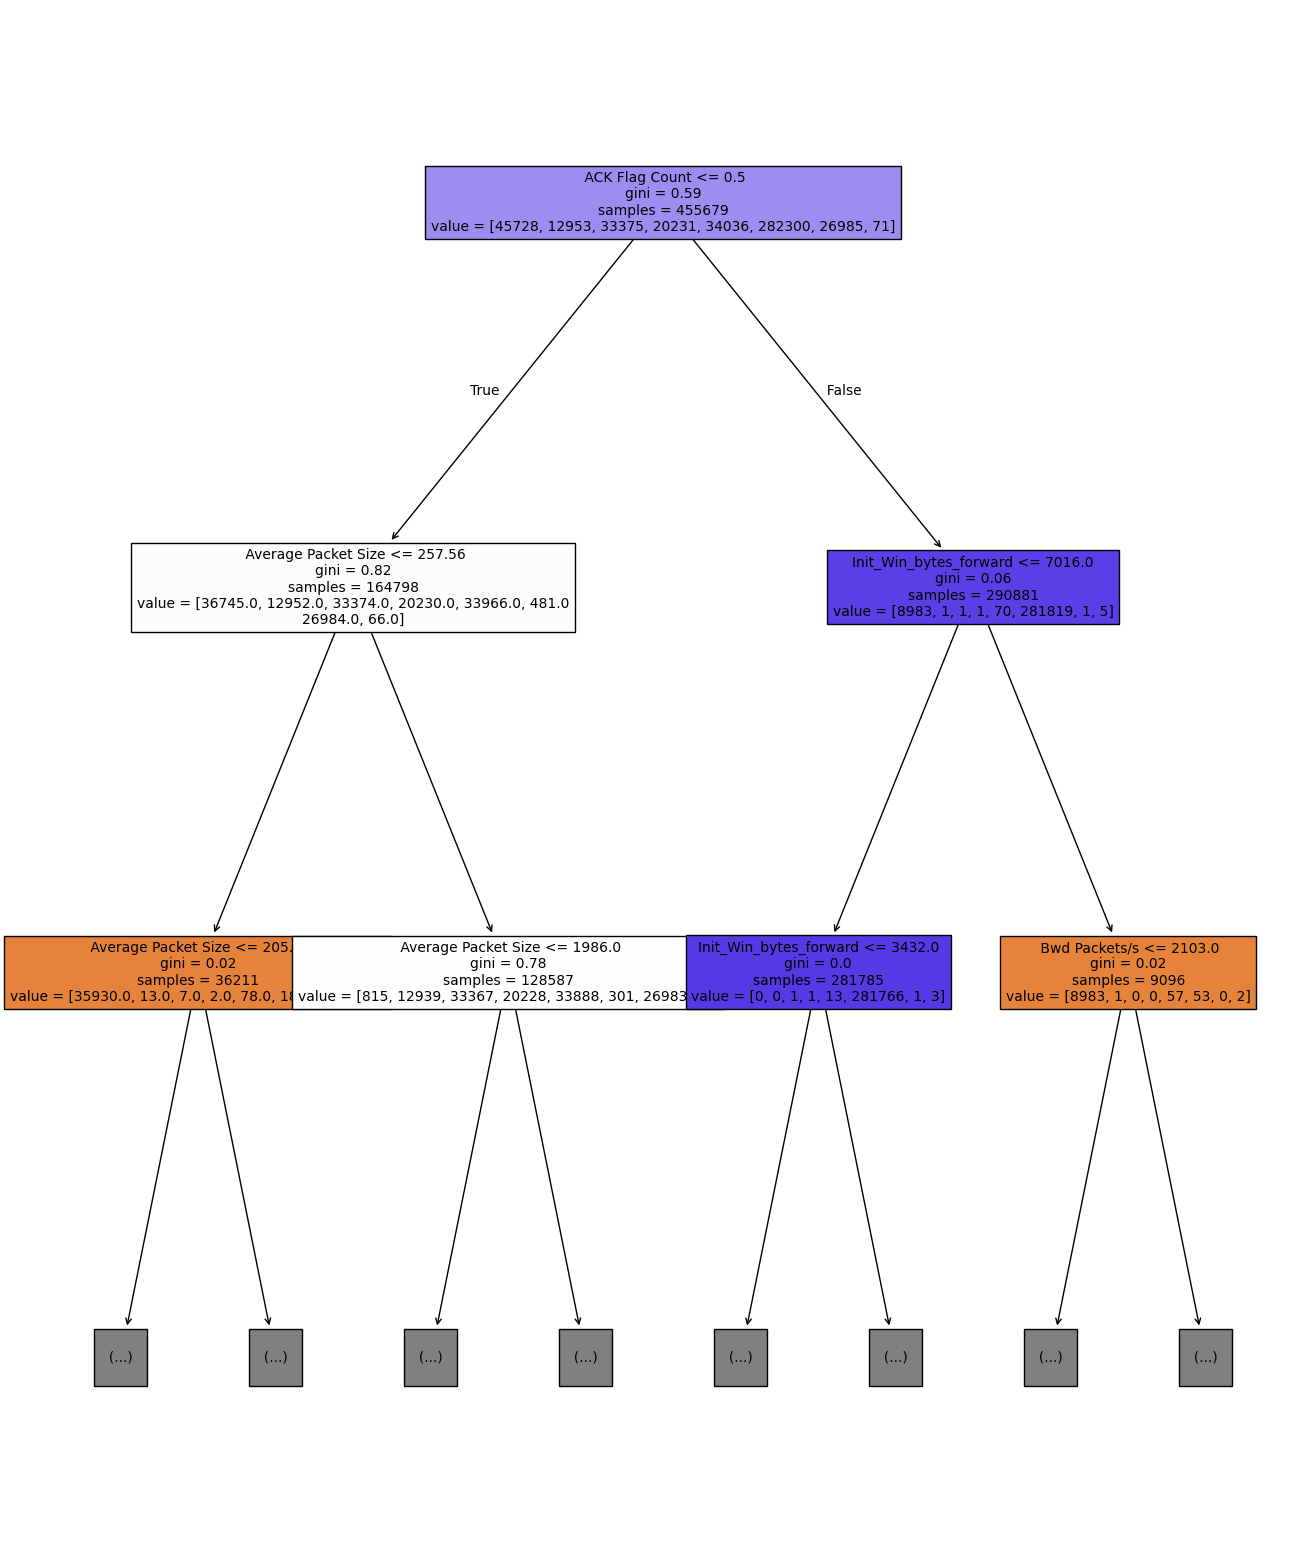

In [45]:
plt.figure(figsize=(16,20))  # Larger figure size for better readability
tree.plot_tree(
    Tree,
    max_depth=2,
    feature_names=X_selected.columns,
    filled=True,
    fontsize=10,          # Increase font size for larger boxes
    precision=2           # Limit decimal places for clarity
)
plt.show()

In [46]:
y_pred = Tree.predict(X_test)

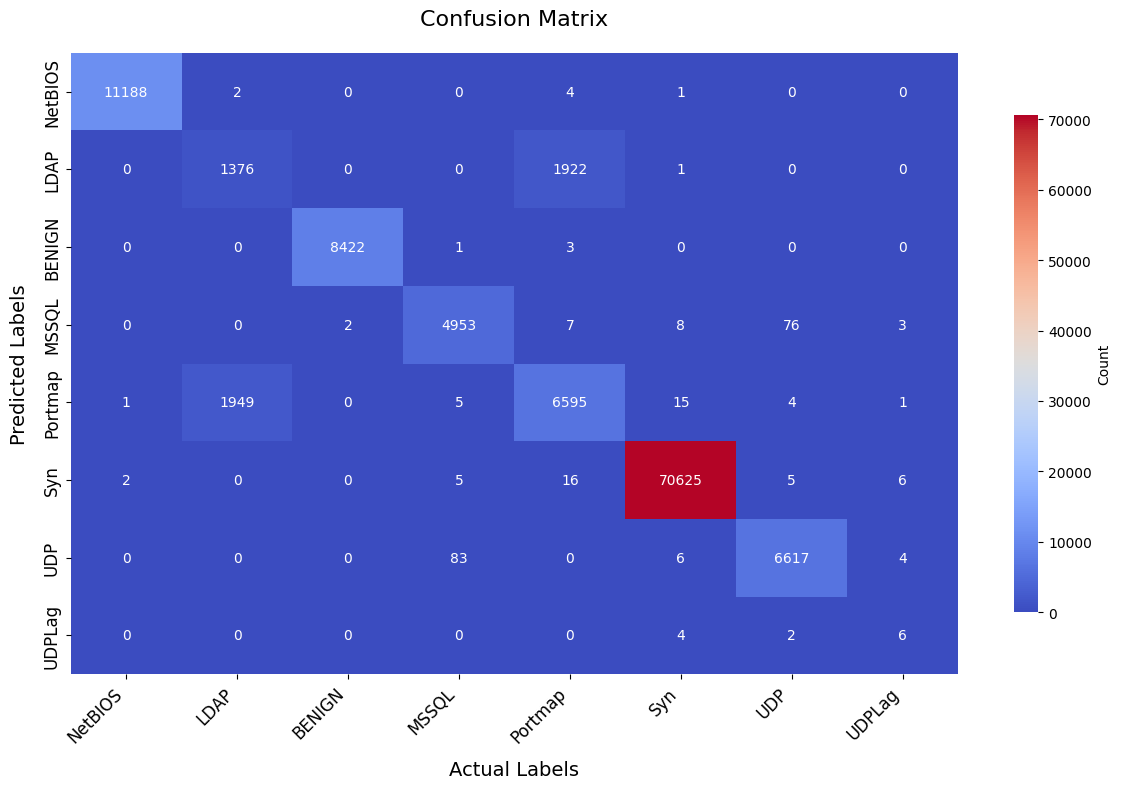

In [58]:
confusion = metrics.confusion_matrix(y_test,y_pred)
plt.figure(figsize=(12, 8))

# Use seaborn heatmap with additional styling
sns.heatmap(
    confusion,
    annot=True,              # Annotate cells with values
    fmt="g",                 # Display integer values instead of scientific notation
    cmap="coolwarm",         # Use a visually appealing color map
    xticklabels=Output,  # Set column names for x-axis
    yticklabels=Output,  # Set column names for y-axis
    cbar_kws={"shrink": 0.8, "label": "Count"}  # Adjust color bar size and add label
)

# Improve labels and title
plt.xlabel("Actual Labels", fontsize=14, labelpad=10)
plt.ylabel("Predicted Labels", fontsize=14, labelpad=10)
plt.title("Confusion Matrix", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# Show gridlines for better readability
plt.grid(False)

# Display the plot
plt.tight_layout()
plt.show()

In [56]:
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred, target_names=Output))


Classification Report:
               precision    recall  f1-score   support

     NetBIOS       1.00      1.00      1.00     11195
        LDAP       0.41      0.42      0.42      3299
      BENIGN       1.00      1.00      1.00      8426
       MSSQL       0.98      0.98      0.98      5049
     Portmap       0.77      0.77      0.77      8570
         Syn       1.00      1.00      1.00     70659
         UDP       0.99      0.99      0.99      6710
      UDPLag       0.30      0.50      0.38        12

    accuracy                           0.96    113920
   macro avg       0.81      0.83      0.82    113920
weighted avg       0.96      0.96      0.96    113920



In [59]:
Acc = metrics.accuracy_score(y_test,y_pred)
print(Acc*100)

96.36762640449437


In [65]:
precision = metrics.precision_score(y_test,y_pred,average='weighted')
print(f"Precision: {precision*100}")

Precision: 96.3822424459045


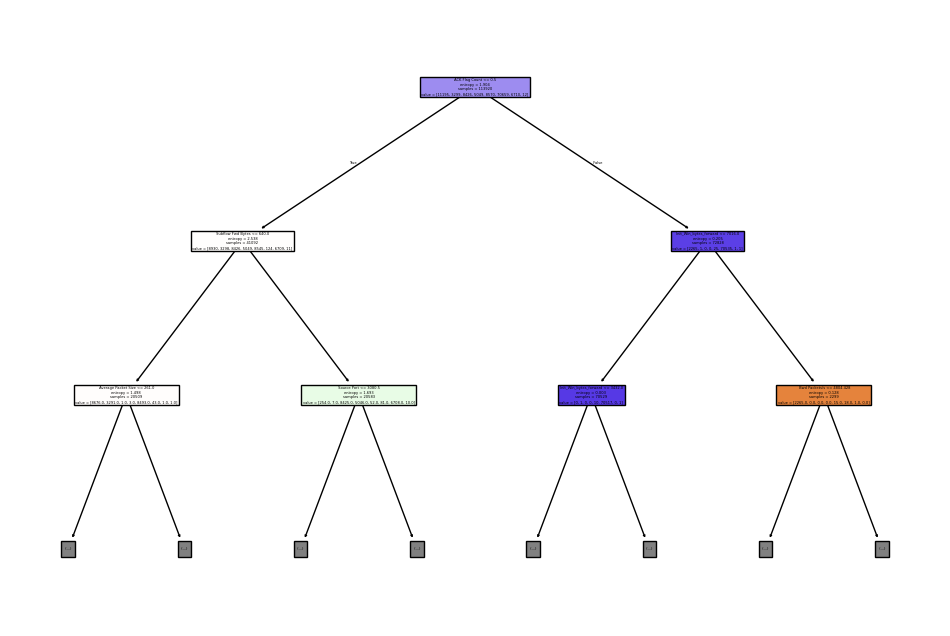

In [67]:
model = DecisionTreeClassifier(criterion='entropy', splitter='best')
model.fit(X_test, y_test)

# Visualize the tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
tree.plot_tree(model,max_depth=2, feature_names=X_test.columns, filled=True)
plt.show()